# SCT_DS_Task3
## Decision Tree Classifier — Bank Marketing Dataset

**Internship:** SkillCraft Technology  
**Task:** Decision Tree Classifier  
**Dataset:** Bank Marketing Dataset

In [4]:
import zipfile
import os

zip_path = "/content/bank+marketing.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/bank_marketing")

print("Files extracted:")
print(os.listdir("/content/bank_marketing"))

Files extracted:
['bank-additional.zip', 'bank.zip']


In [5]:
import zipfile
import os

bank_zip = "/content/bank_marketing/bank.zip"

with zipfile.ZipFile(bank_zip, 'r') as zip_ref:
    zip_ref.extractall("/content/bank_data")

print("Bank dataset files:")
print(os.listdir("/content/bank_data"))

Bank dataset files:
['bank-names.txt', 'bank-full.csv', 'bank.csv']


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/bank_data/bank-full.csv", sep=";")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


df.info()

In [7]:
print(df['y'].value_counts())

print("\nTarget Variable Percentage:")
print(df['y'].value_counts(normalize=True) * 100)


y
no     39922
yes     5289
Name: count, dtype: int64

Target Variable Percentage:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [8]:
df['y'] = df['y'].map({'no': 0, 'yes': 1})

print(df['y'].value_counts())

y
0    39922
1     5289
Name: count, dtype: int64


In [9]:
X = df.drop('y', axis=1)
y = df['y']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (45211, 16)
Target shape: (45211,)


In [10]:
X_encoded = pd.get_dummies(X, drop_first=True)

print("Encoded Features Shape:", X_encoded.shape)
X_encoded.head()

Encoded Features Shape: (45211, 42)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (36168, 42)
Testing set: (9043, 42)


from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

In [14]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [15]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 89.84 %


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.64      0.30      0.41      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.64      0.68      9043
weighted avg       0.88      0.90      0.88      9043



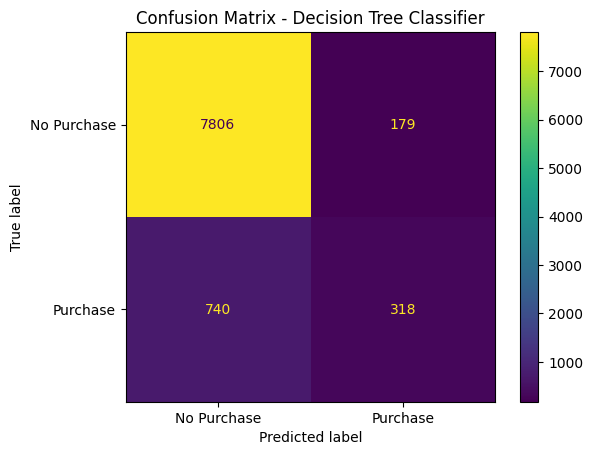

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Purchase', 'Purchase']
)

disp.plot()
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.show()

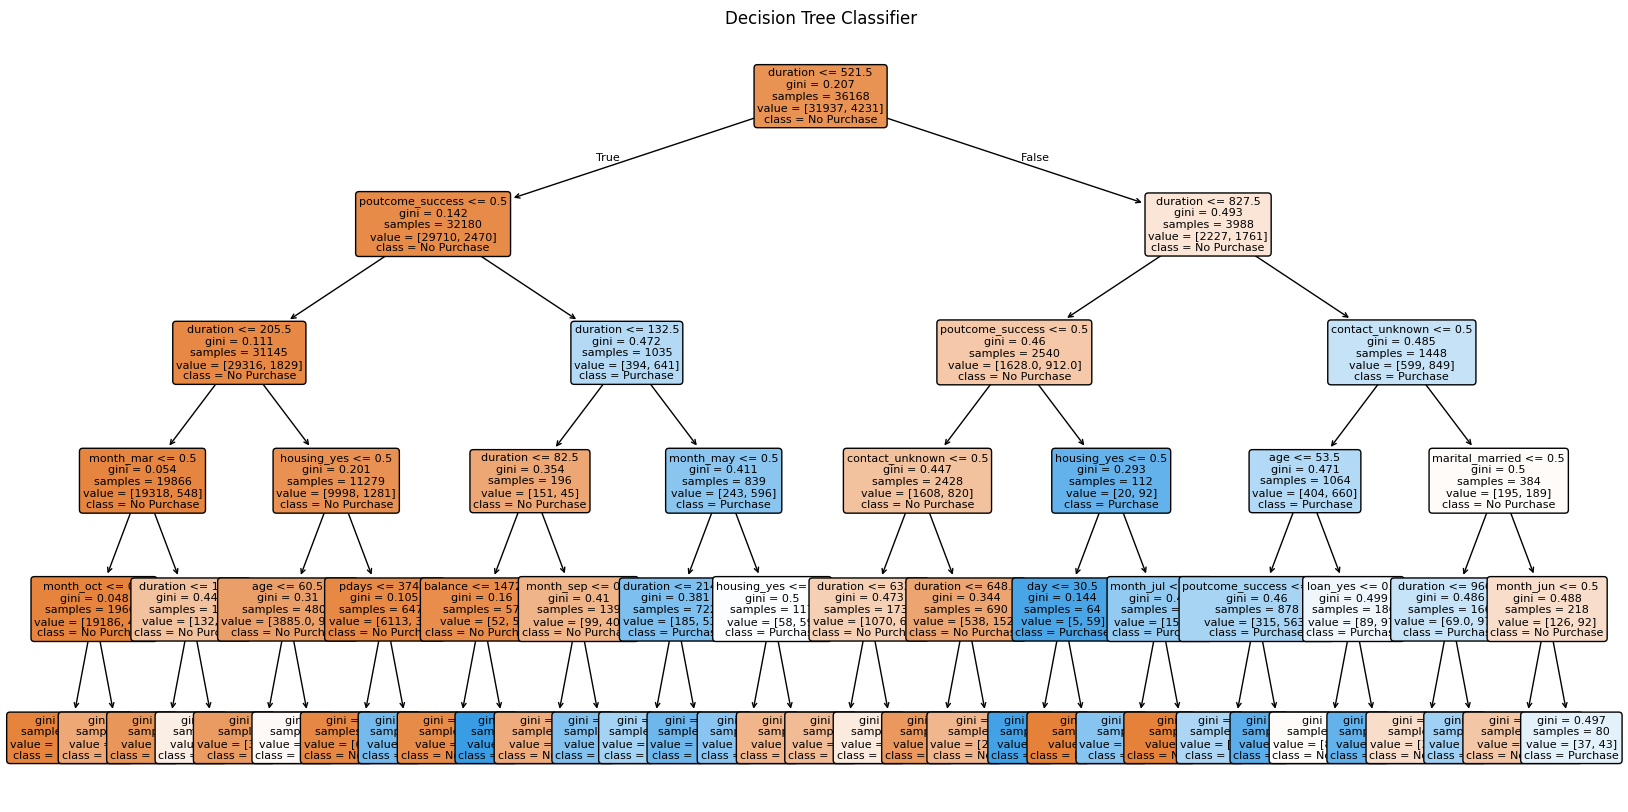

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X_encoded.columns,
    class_names=['No Purchase', 'Purchase'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title('Decision Tree Classifier')
plt.show()

In [20]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

Top 10 Important Features:
duration            0.551016
poutcome_success    0.297207
housing_yes         0.049952
age                 0.026724
pdays               0.017373
month_mar           0.016705
contact_unknown     0.015592
month_oct           0.010170
month_may           0.005023
marital_married     0.002160
dtype: float64


## Key Findings and Conclusion

### Model Performance
- Decision Tree Accuracy: **89.84%**
- Precision for Purchase (1): **64%**
- Recall for Purchase (1): **30%**
- F1-score for Purchase (1): **41%**

### Important Features
The most important features identified by the Decision Tree were:
1. **duration** — 55.10%
2. **poutcome_success** — 29.72%
3. **housing_yes** — 5.00%
4. **age** — 2.67%
5. **pdays** — 1.74%

### Conclusion
A Decision Tree Classifier was successfully developed to predict whether a customer would subscribe to the bank's term deposit. The model achieved **89.84% accuracy** on the test dataset. The feature importance analysis showed that **duration** and **previous campaign outcome (`poutcome_success`)** were the most influential features in the model.

The project provided practical experience in data preprocessing, categorical encoding, train-test splitting, decision tree classification, model evaluation, confusion matrix analysis, and feature importance analysis.